# Part 2: Handling UART input

We will now extend our bare-metal program to handle UART input, echoing back any characters received.

In [1]:
cp ../01_hello/link.ld .
cp ../01_hello/Makefile .
cp ../01_hello/run.sh .
cp ../01_hello/start.S .

For this program, the `main.c` file now defines two status bits for the `UART0_FR` flag register: `UART_FR_TXFF` (Transmit FIFO Full) and `UART_FR_RXFE` (Receive FIFO Empty). These bits are used to check the status of the UART before sending or receiving data.

In [2]:
batcat --terminal-width 110 -r 10:14 main.c

───────┬──────────────────────────────────────────────────────────────────────────────────────────────────────
       │ File: main.c
───────┼──────────────────────────────────────────────────────────────────────────────────────────────────────
  10   │ /** Status mask: transmit buffer full? */
  11   │ #define UART0_FR_TXFF (1 << 5)
  12   │ 
  13   │ /** Status mask: receive buffer empty? */
  14   │ #define UART0_FR_RXFE (1 << 4)
───────┴──────────────────────────────────────────────────────────────────────────────────────────────────────


In [3]:
batcat --terminal-width 110 -r 19:25 main.c

───────┬──────────────────────────────────────────────────────────────────────────────────────────────────────
       │ File: main.c
───────┼──────────────────────────────────────────────────────────────────────────────────────────────────────
  19   │ /** Output a character to the UART0 console */
  20   │ static void uart_putc(char c)
  21   │ {
  22   │     while (UART0_FR & UART0_FR_TXFF)
  23   │         ;
  24   │     UART0_DR = (unsigned int)c;
  25   │ }
───────┴──────────────────────────────────────────────────────────────────────────────────────────────────────


In [4]:
batcat --terminal-width 110 -r 35:47 main.c

───────┬──────────────────────────────────────────────────────────────────────────────────────────────────────
       │ File: main.c
───────┼──────────────────────────────────────────────────────────────────────────────────────────────────────
  35   │ /** Block until a character is received from the UART0 console */
  36   │ static char uart_getc(void)
  37   │ {
  38   │     while (1) {
  39   │         while (UART0_FR & UART0_FR_RXFE)
  40   │             ;
  41   │         char c = (char)(UART0_DR & 0xFF);
  42   │     
  43   │         /** Printable ASCII character or specific special characters only */
  44   │         if ((c >= 32 && c <= 126) || c == '\r' || c == '\n' || c == 0x1b || c == '\b')
  45   │             return c;
  46   │     }
  47   │ }
───────┴──────────────────────────────────────────────────────────────────────────────────────────────────────


The remainder of `main.c` is relatively straightforward, however, some special handling is applied
for special character handling, such as backspaces and carriage returns.

In [5]:
./run.sh

aarch64-linux-gnu-gcc -march=armv8-a -mabi=lp64 -mgeneral-regs-only -mstrict-align -ffreestanding -fno-stack-protector -fno-pic -O2 -Wall -nostdlib -static -Wl,-T,link.ld -o start.elf start.S main.c


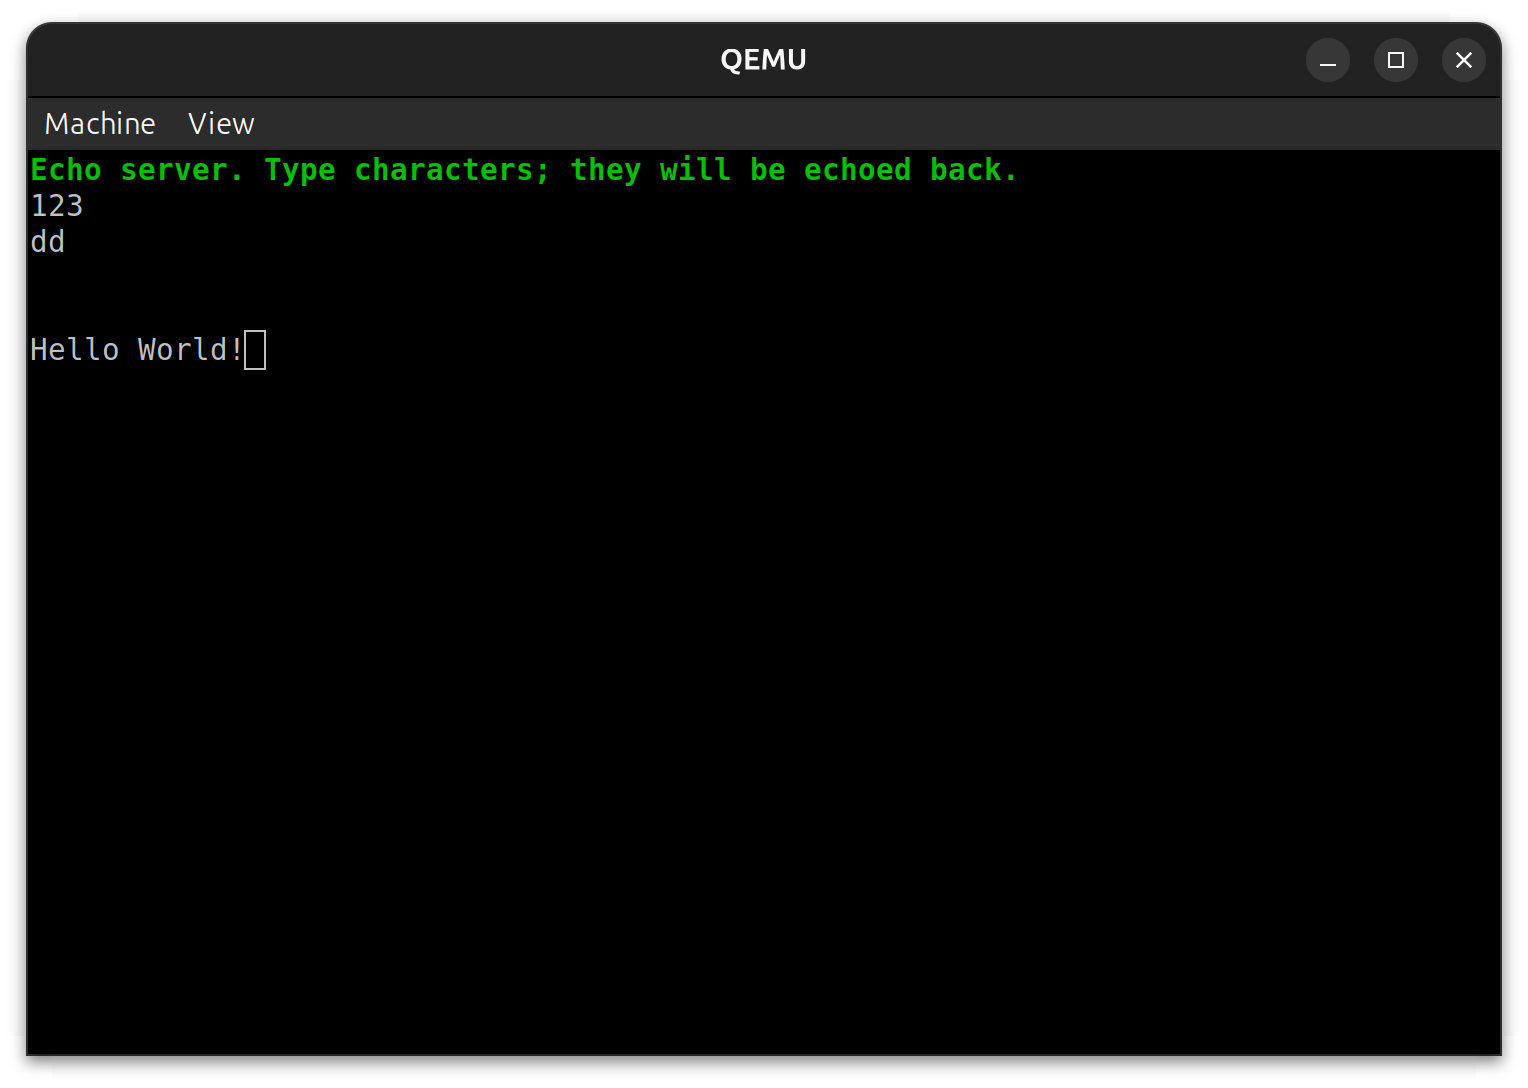

## CPU usage

The current program busy-loops until a character is received from the UART0 console, which can lead to high CPU usage even when no input is available. In Part 3, we will show how to use interrupts to handle UART input more efficiently.